# DriveVal — Car Selling Price Analysis & Prediction
**IBM SkillsBuild Data Analytics with AI Academic Internship Project**  
**Author:** Faisal Mohsin  
**Dataset:** Car Sell Dataset.csv  

---

## Project Structure
1. Environment Setup & Data Loading
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Baseline Machine Learning Model (Price Prediction)
6. Model Evaluation & Insights
7. Conclusion & Recommendations

---
## 1. Environment Setup & Data Loading

In [1]:
# ── Core libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Machine Learning ────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Warnings ────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ── Load dataset ────────────────────────────────────────────────────────────
df_raw = pd.read_csv('Car Sell Dataset.csv')

print(f'Shape : {df_raw.shape}')
print(f'Columns : {list(df_raw.columns)}')
df_raw.head()

Shape : (140904, 12)
Columns : ['Brand', 'Model Name', 'Model Variant', 'Car Type', 'Transmission', 'Fuel Type', 'Year', 'Kilometers', 'Owner', 'State', 'Accidental', 'Price']


,Brand,Model Name,Model Variant,Car Type,Transmission,Fuel Type,Year,Kilometers,Owner,State,Accidental,Price
0,Mahindra,TUV300,AX5,SUV,Manual,CNG,2017,164654,1st,Rajasthan,No,547253
1,Skoda,Rapid,Style,Sedan,Manual,Petrol,2018,41351,1st,Maharashtra,No,512050
2,Maruti Suzuki,Alto,Z,Hatchback,Manual,Diesel,2002,119090,3rd+,Tamil Nadu,No,678923
3,Hyundai,Grand i10,Magna,Hatchback,Manual,Diesel,2013,19979,1st,Andhra Pradesh,No,522500
4,Mahindra,XUV500,W8,SUV,Manual,Petrol,2011,130591,3rd+,Bihar,No,401182


---
## 2. Data Cleaning & Preprocessing

Steps covered:
- Inspect dtypes and null values
- Rename columns for convenience
- Remove duplicate rows
- Correct data types (Year, Kilometers, Price)
- Impute or drop missing values
- Encode the `Owner` ordinal column

In [3]:
# ── Initial inspection ───────────────────────────────────────────────────────
print('=== Data Types ===')
print(df_raw.dtypes)
print('\n=== Missing Values ===')
print(df_raw.isnull().sum())
print(f'\nDuplicate rows: {df_raw.duplicated().sum()}')

=== Data Types ===
Brand            object
Model Name       object
Model Variant    object
Car Type         object
Transmission     object
Fuel Type        object
Year              int64
Kilometers        int64
Owner            object
State            object
Accidental       object
Price             int64
dtype: object

=== Missing Values ===
Brand            0
Model Name       0
Model Variant    0
Car Type         0
Transmission     0
Fuel Type        0
Year             0
Kilometers       0
Owner            0
State            0
Accidental       0
Price            0
dtype: int64

Duplicate rows: 0


In [4]:
# ── Working copy ─────────────────────────────────────────────────────────────
df = df_raw.copy()

# Standardise column names (lowercase, underscores)
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_', regex=False)
)
print('Renamed columns:', list(df.columns))

Renamed columns: ['brand', 'model_name', 'model_variant', 'car_type', 'transmission', 'fuel_type', 'year', 'kilometers', 'owner', 'state', 'accidental', 'price']


In [5]:
# ── Remove duplicate rows ─────────────────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Removed {before - len(df)} duplicate rows. Remaining rows: {len(df)}')

Removed 0 duplicate rows. Remaining rows: 140904


In [6]:
# ── Ensure correct numeric dtypes ────────────────────────────────────────────
for col in ['year', 'kilometers', 'price']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Numeric conversions applied.')
print(df[['year', 'kilometers', 'price']].dtypes)

Numeric conversions applied.
year          int64
kilometers    int64
price         int64
dtype: object


In [7]:
# ── Handle missing values ─────────────────────────────────────────────────────
# Drop rows where the target (price) is missing — cannot impute a label
df.dropna(subset=['price'], inplace=True)

# For other numeric columns impute with median
for col in ['year', 'kilometers']:
    median_val = df[col].median()
    missing = df[col].isnull().sum()
    df[col].fillna(median_val, inplace=True)
    if missing:
        print(f'Imputed {missing} missing values in "{col}" with median {median_val}')

# For categorical columns impute with mode
cat_cols = ['brand', 'model_name', 'model_variant', 'car_type',
            'transmission', 'fuel_type', 'owner', 'state', 'accidental']
for col in cat_cols:
    if col in df.columns:
        missing = df[col].isnull().sum()
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        if missing:
            print(f'Imputed {missing} missing values in "{col}" with mode "{mode_val}"')

print(f'\nNull values remaining: {df.isnull().sum().sum()}')
print(f'Final dataset shape : {df.shape}')


Null values remaining: 0
Final dataset shape : (140904, 12)


In [8]:
# ── Encode ordinal Owner column ───────────────────────────────────────────────
owner_order = {'1st': 1, '2nd': 2, '3rd': 3, '3rd+': 4}
df['owner_num'] = df['owner'].map(owner_order)
# Fill any unmapped entries with median
df['owner_num'].fillna(df['owner_num'].median(), inplace=True)

# Binary encode 'accidental'
df['accidental_flag'] = (df['accidental'].str.strip().str.lower() == 'yes').astype(int)

# Derive car age from year
current_year = 2025
df['car_age'] = current_year - df['year']

print('Feature derivation complete.')
df[['owner', 'owner_num', 'accidental', 'accidental_flag', 'year', 'car_age']].head(3)

Feature derivation complete.


,owner,owner_num,accidental,accidental_flag,year,car_age
0,1st,1,No,0,2017,8
1,1st,1,No,0,2018,7
2,3rd+,4,No,0,2002,23


In [9]:
# ── Basic statistical summary ─────────────────────────────────────────────────
df[['price', 'kilometers', 'car_age', 'owner_num']].describe().round(2)

,price,kilometers,car_age,owner_num
count,140904.00,140904.00,140904.00,140904.00
mean,761787.17,95024.60,8.04,1.59
std,443857.75,49133.16,5.11,0.79
min,50055.00,10000.00,2.00,1.00
25%,411642.00,52421.00,4.00,1.00
50%,682803.00,94973.50,7.00,1.00
75%,1034178.25,137618.00,11.00,2.00
max,2744280.00,179998.00,25.00,4.00


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable — Price Distribution

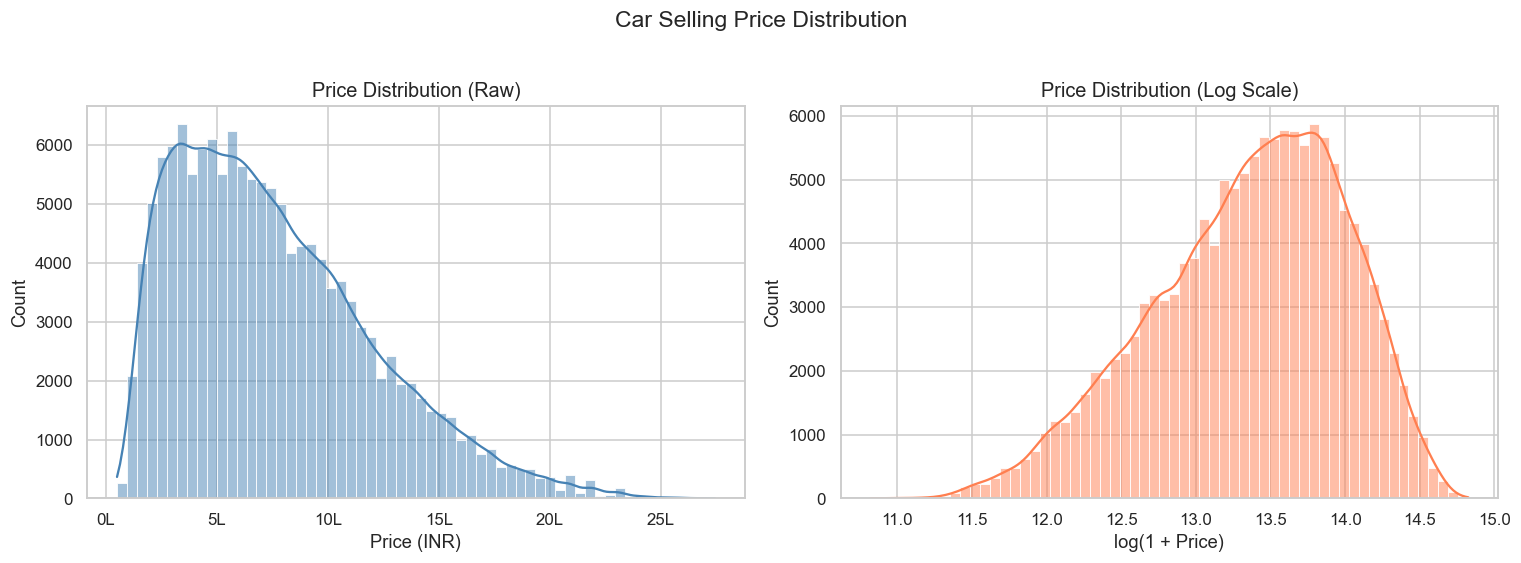

Price  |  Mean: ₹761,787  |  Median: ₹682,803  |  Std: ₹443,858


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price
sns.histplot(df['price'], kde=True, ax=axes[0], color='steelblue', bins=60)
axes[0].set_title('Price Distribution (Raw)', fontsize=13)
axes[0].set_xlabel('Price (INR)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e5:.0f}L'))

# Log-transformed price
sns.histplot(np.log1p(df['price']), kde=True, ax=axes[1], color='coral', bins=60)
axes[1].set_title('Price Distribution (Log Scale)', fontsize=13)
axes[1].set_xlabel('log(1 + Price)')

plt.suptitle('Car Selling Price Distribution', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('plot_price_distribution.png', bbox_inches='tight')
plt.show()
print(f'Price  |  Mean: ₹{df["price"].mean():,.0f}  |  Median: ₹{df["price"].median():,.0f}  |  Std: ₹{df["price"].std():,.0f}')

### 3.2 Sales Count by Brand (Top 15)

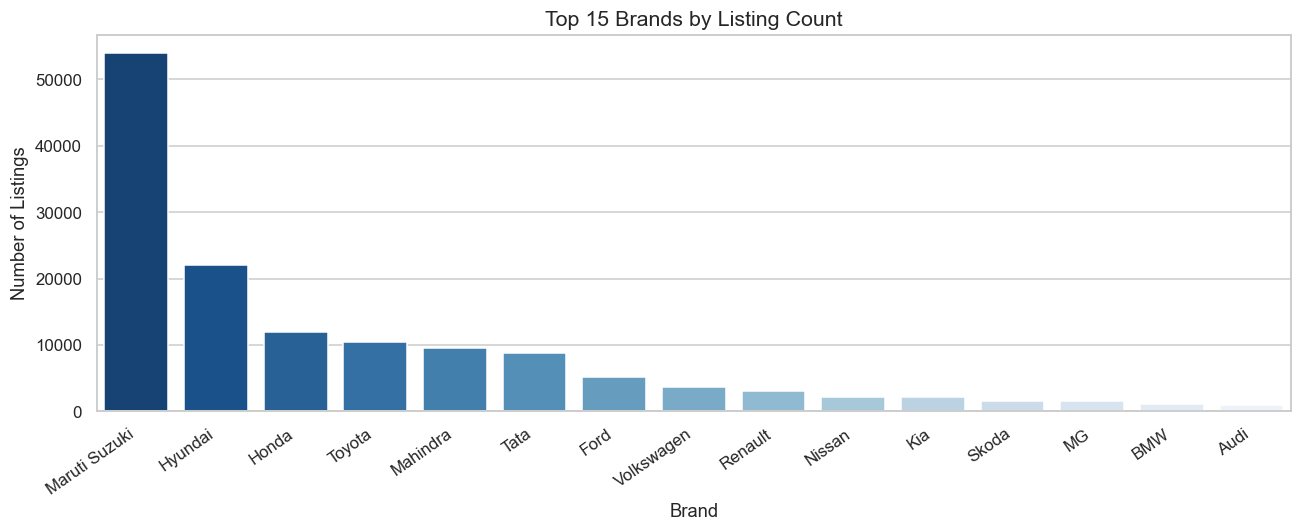

In [11]:
top_brands = df['brand'].value_counts().head(15)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_brands.index, y=top_brands.values, palette='Blues_r')
plt.title('Top 15 Brands by Listing Count', fontsize=14)
plt.xlabel('Brand')
plt.ylabel('Number of Listings')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('plot_top_brands.png', bbox_inches='tight')
plt.show()

### 3.3 Average Price by Brand (Top 15)

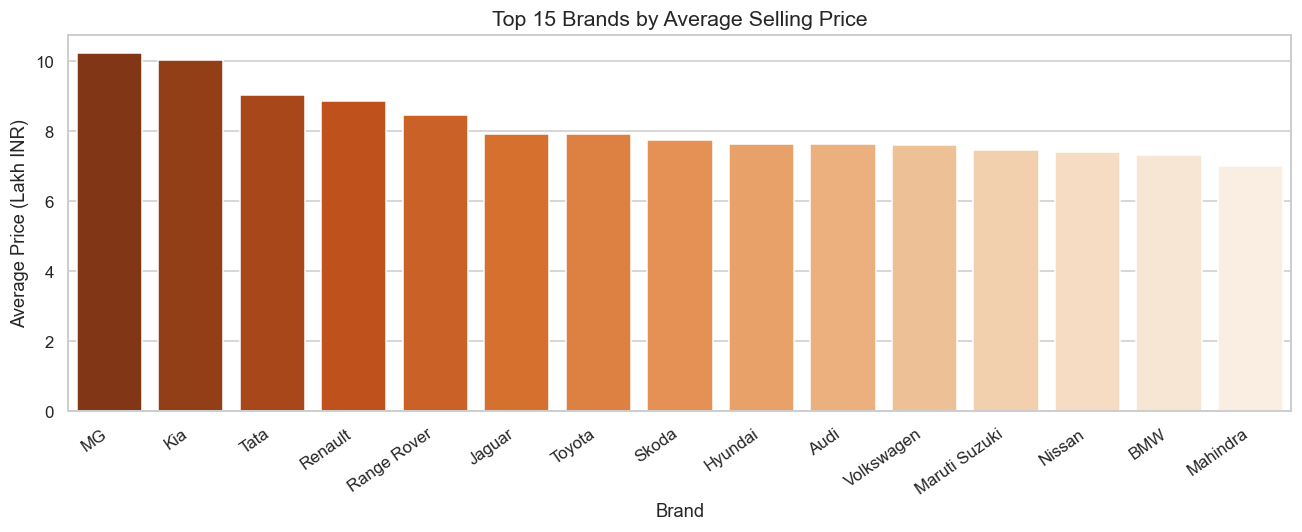

In [12]:
brand_price = (
    df.groupby('brand')['price']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 5))
sns.barplot(x=brand_price.index, y=brand_price.values / 1e5, palette='Oranges_r')
plt.title('Top 15 Brands by Average Selling Price', fontsize=14)
plt.xlabel('Brand')
plt.ylabel('Average Price (Lakh INR)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('plot_avg_price_brand.png', bbox_inches='tight')
plt.show()

### 3.4 Price by Fuel Type

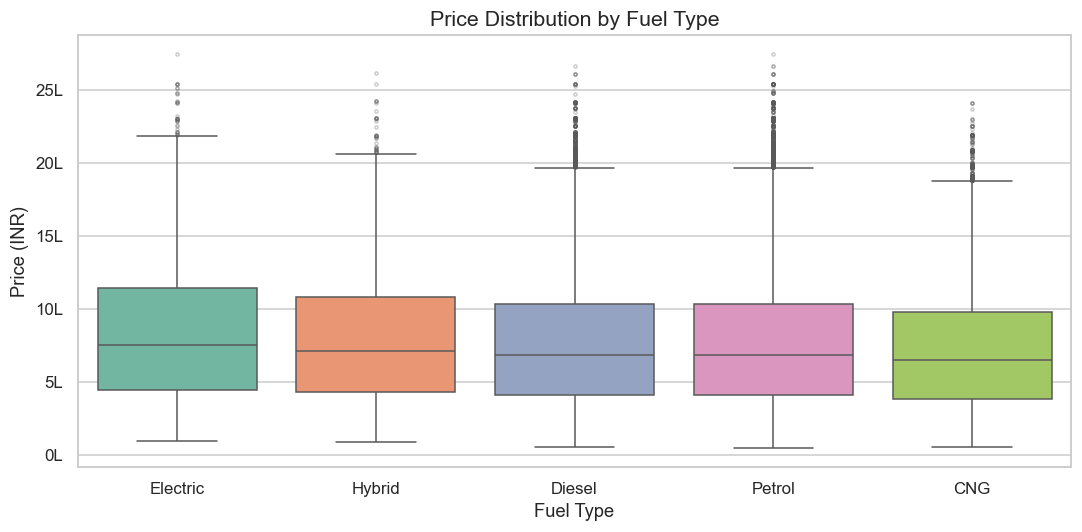

In [13]:
plt.figure(figsize=(10, 5))
order = df.groupby('fuel_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='fuel_type', y='price', order=order, palette='Set2',
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
plt.title('Price Distribution by Fuel Type', fontsize=14)
plt.xlabel('Fuel Type')
plt.ylabel('Price (INR)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e5:.0f}L'))
plt.tight_layout()
plt.savefig('plot_price_fuel.png', bbox_inches='tight')
plt.show()

### 3.5 Price by Transmission Type

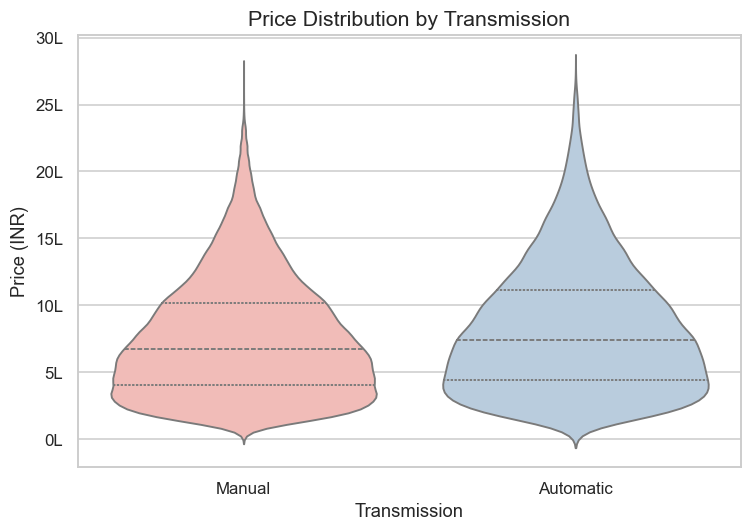

In [14]:
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x='transmission', y='price', palette='Pastel1', inner='quartile')
plt.title('Price Distribution by Transmission', fontsize=14)
plt.xlabel('Transmission')
plt.ylabel('Price (INR)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e5:.0f}L'))
plt.tight_layout()
plt.savefig('plot_price_transmission.png', bbox_inches='tight')
plt.show()

### 3.6 Price vs Car Age (Scatter)

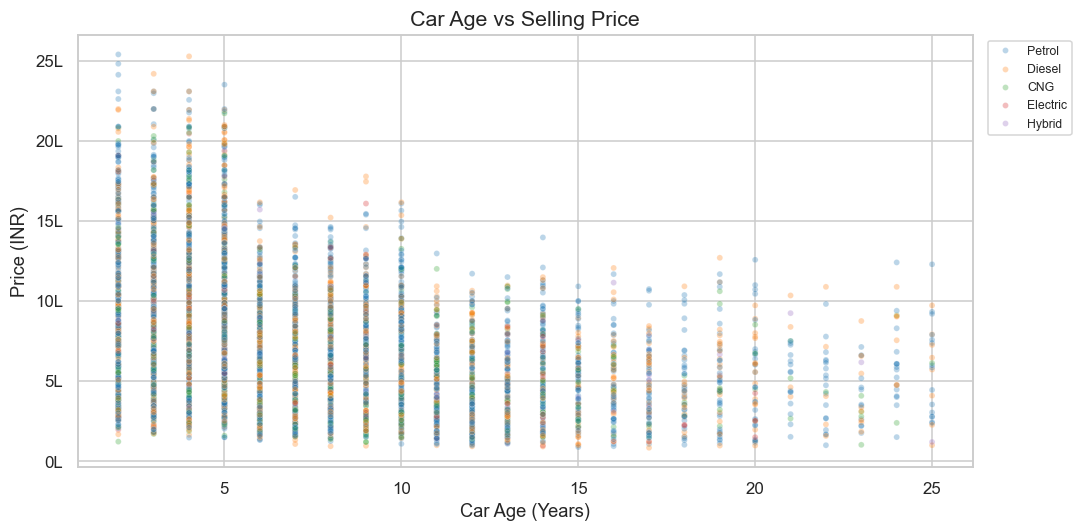

In [15]:
sample = df.sample(min(5000, len(df)), random_state=42)

plt.figure(figsize=(10, 5))
sns.scatterplot(data=sample, x='car_age', y='price', alpha=0.3,
                hue='fuel_type', s=15, palette='tab10')
plt.title('Car Age vs Selling Price', fontsize=14)
plt.xlabel('Car Age (Years)')
plt.ylabel('Price (INR)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e5:.0f}L'))
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('plot_age_vs_price.png', bbox_inches='tight')
plt.show()

### 3.7 Price vs Kilometers Driven

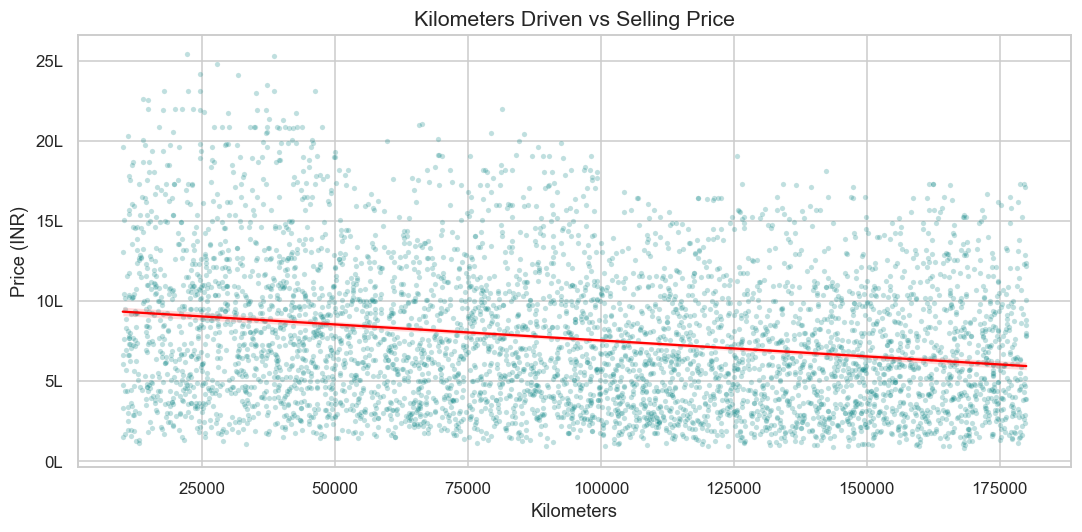

In [16]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=sample, x='kilometers', y='price', alpha=0.25, s=12, color='teal')
sns.regplot(data=sample, x='kilometers', y='price', scatter=False,
            color='red', line_kws={'linewidth': 1.5})
plt.title('Kilometers Driven vs Selling Price', fontsize=14)
plt.xlabel('Kilometers')
plt.ylabel('Price (INR)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e5:.0f}L'))
plt.tight_layout()
plt.savefig('plot_km_vs_price.png', bbox_inches='tight')
plt.show()

### 3.8 Correlation Heatmap

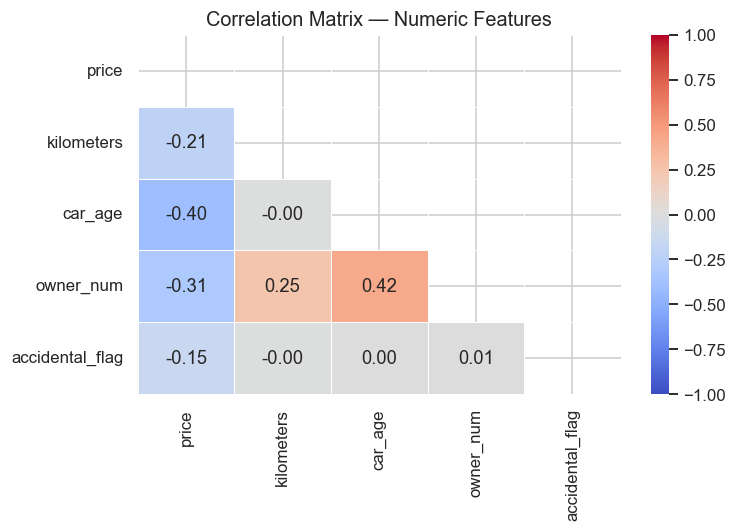

In [17]:
numeric_cols = ['price', 'kilometers', 'car_age', 'owner_num', 'accidental_flag']
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Numeric Features', fontsize=13)
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', bbox_inches='tight')
plt.show()

### 3.9 Listings per State (Top 15)

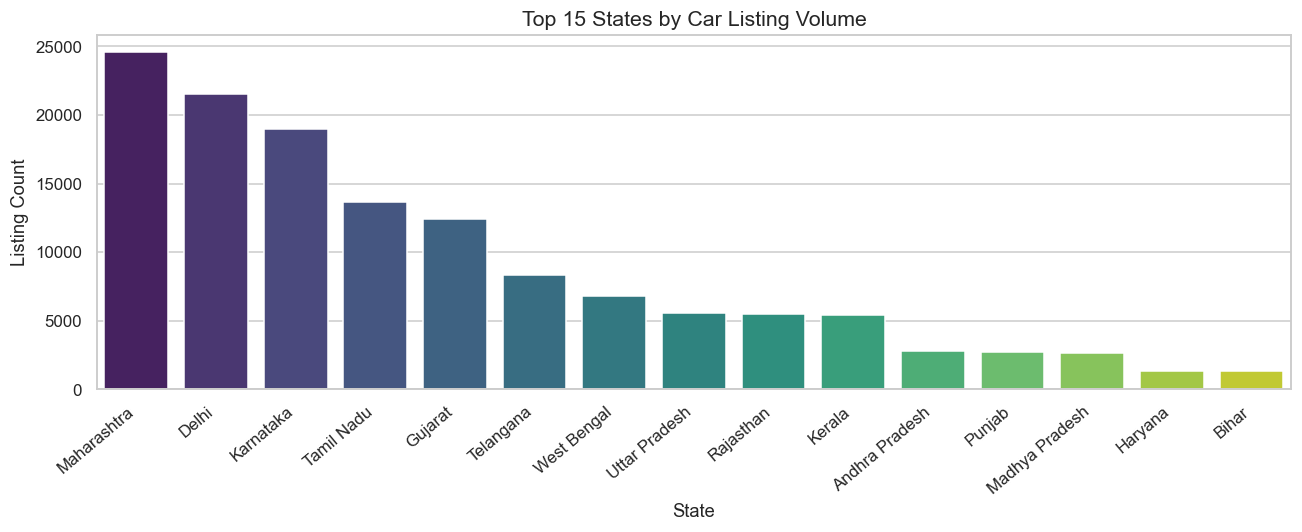

In [18]:
top_states = df['state'].value_counts().head(15)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_states.index, y=top_states.values, palette='viridis')
plt.title('Top 15 States by Car Listing Volume', fontsize=14)
plt.xlabel('State')
plt.ylabel('Listing Count')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('plot_state_listings.png', bbox_inches='tight')
plt.show()

### 3.10 Yearly Listing Trend

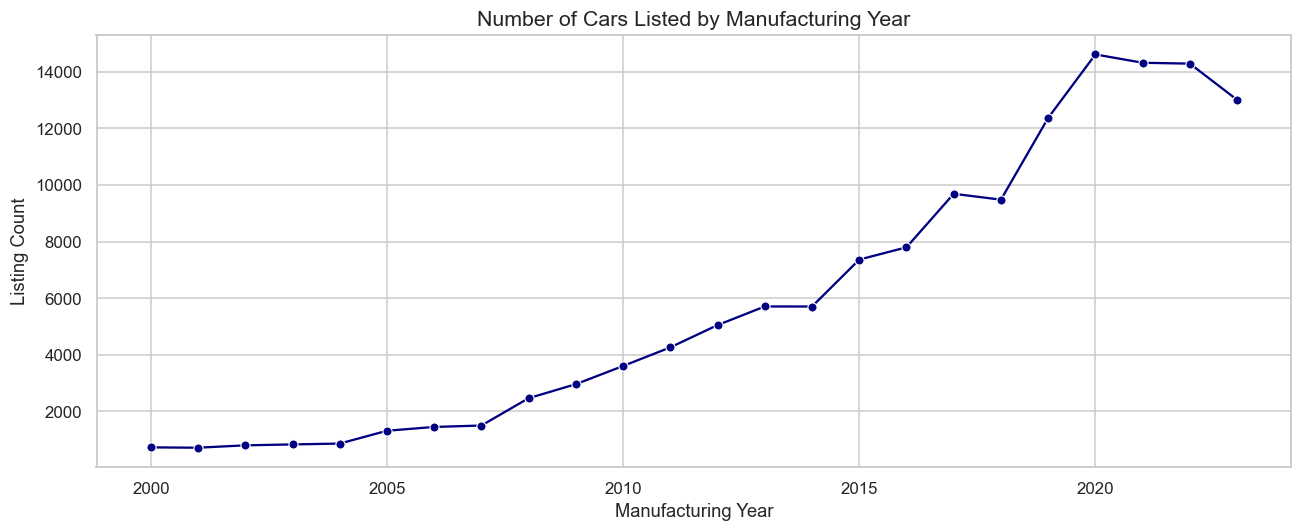

In [19]:
yearly = df.groupby('year').size().reset_index(name='count')
yearly = yearly[(yearly['year'] >= 2000) & (yearly['year'] <= 2024)]

plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly, x='year', y='count', marker='o', color='navy')
plt.title('Number of Cars Listed by Manufacturing Year', fontsize=14)
plt.xlabel('Manufacturing Year')
plt.ylabel('Listing Count')
plt.tight_layout()
plt.savefig('plot_yearly_trend.png', bbox_inches='tight')
plt.show()

### 3.11 Car Type Distribution

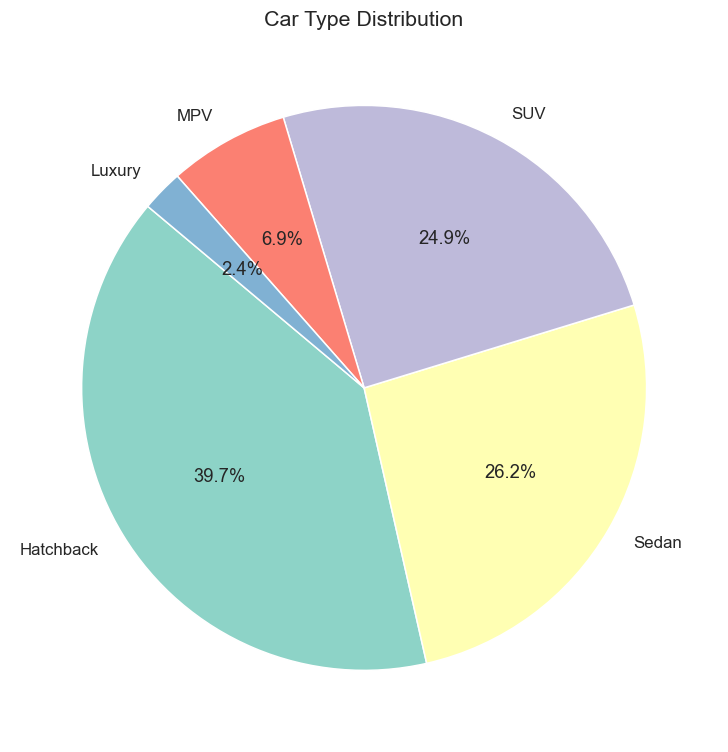

In [20]:
type_counts = df['car_type'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('Set3', len(type_counts)))
plt.title('Car Type Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('plot_car_type_pie.png', bbox_inches='tight')
plt.show()

### 3.12 Accidental vs Non-Accidental Price Comparison

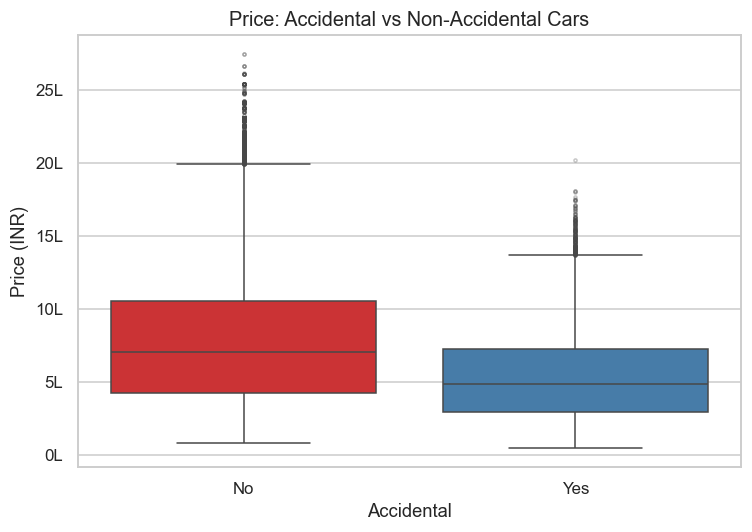

Median price — Accidental: ₹484,621 | Non-Accidental: ₹703,395
Price discount for accidental cars: 31.1%


In [21]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='accidental', y='price', palette='Set1',
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
plt.title('Price: Accidental vs Non-Accidental Cars', fontsize=13)
plt.xlabel('Accidental')
plt.ylabel('Price (INR)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e5:.0f}L'))
plt.tight_layout()
plt.savefig('plot_accidental_price.png', bbox_inches='tight')
plt.show()

# Quantify the price gap
acc_median  = df.loc[df['accidental_flag']==1, 'price'].median()
nacc_median = df.loc[df['accidental_flag']==0, 'price'].median()
print(f'Median price — Accidental: ₹{acc_median:,.0f} | Non-Accidental: ₹{nacc_median:,.0f}')
print(f'Price discount for accidental cars: {((nacc_median - acc_median)/nacc_median)*100:.1f}%')

---
## 4. Feature Engineering

Prepare a modelling-ready dataset by:
- One-hot encoding low-cardinality categorical features
- Label-encoding high-cardinality features (Brand)
- Using log-transformed price as the regression target

In [22]:
# ── Features selected for modelling ──────────────────────────────────────────
FEATURES = [
    'car_age', 'kilometers', 'owner_num', 'accidental_flag',
    'fuel_type', 'transmission', 'car_type'
]
TARGET = 'price'

df_model = df[FEATURES + [TARGET]].copy()

# Log-transform the target to reduce skew
df_model['log_price'] = np.log1p(df_model[TARGET])

# One-hot encode low-cardinality categoricals
cat_ohe = ['fuel_type', 'transmission', 'car_type']
df_model = pd.get_dummies(df_model, columns=cat_ohe, drop_first=True)

# Ensure all boolean dummies are int
bool_cols = df_model.select_dtypes('bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print(f'Modelling dataset shape: {df_model.shape}')
df_model.head(2)

Modelling dataset shape: (140904, 15)


,car_age,kilometers,owner_num,accidental_flag,price,log_price,fuel_type_Diesel,fuel_type_Electric,fuel_type_Hybrid,fuel_type_Petrol,transmission_Manual,car_type_Luxury,car_type_MPV,car_type_SUV,car_type_Sedan
0,8,164654,1,0,547253,13.212668,0,0,0,0,1,0,0,1,0
1,7,41351,1,0,512050,13.146180,0,0,0,1,1,0,0,0,1


In [23]:
# ── Train / Test split ────────────────────────────────────────────────────────
X = df_model.drop(columns=[TARGET, 'log_price'])
y = df_model['log_price']           # predict log price; inverse-transform for evaluation

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for linear models)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')

Train size: 112,723 | Test size: 28,181


---
## 5. Machine Learning Model Training

We train four models of increasing complexity:
1. Linear Regression (baseline)
2. Ridge Regression (L2-regularised linear)
3. Random Forest Regressor
4. Gradient Boosting Regressor

In [24]:
def evaluate(model, X_tr, X_te, y_tr, y_te, name):
    """Fit a model, return a results dict with key regression metrics."""
    model.fit(X_tr, y_tr)
    preds_log = model.predict(X_te)

    # Inverse-transform from log space
    preds = np.expm1(preds_log)
    actuals = np.expm1(y_te)

    mae   = mean_absolute_error(actuals, preds)
    rmse  = np.sqrt(mean_squared_error(actuals, preds))
    r2    = r2_score(actuals, preds)

    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
            'preds': preds, 'actuals': actuals}

models = [
    (LinearRegression(),               X_train_sc, X_test_sc, 'Linear Regression'),
    (Ridge(alpha=10),                  X_train_sc, X_test_sc, 'Ridge Regression'),
    (RandomForestRegressor(
        n_estimators=150, max_depth=12,
        min_samples_leaf=5, random_state=42, n_jobs=-1),
     X_train, X_test, 'Random Forest'),
    (GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.08,
        max_depth=5, random_state=42, subsample=0.8),
     X_train, X_test, 'Gradient Boosting'),
]

results = []
for mdl, Xtr, Xte, name in models:
    res = evaluate(mdl, Xtr, Xte, y_train, y_test, name)
    results.append(res)
    print(f'{name:25s} | MAE: ₹{res["MAE"]:>10,.0f} | RMSE: ₹{res["RMSE"]:>10,.0f} | R²: {res["R2"]:.4f}')

Linear Regression         | MAE: ₹   311,923 | RMSE: ₹   391,719 | R²: 0.2191
Ridge Regression          | MAE: ₹   311,924 | RMSE: ₹   391,722 | R²: 0.2190
Random Forest             | MAE: ₹   306,522 | RMSE: ₹   379,869 | R²: 0.2656
Gradient Boosting         | MAE: ₹   305,822 | RMSE: ₹   378,636 | R²: 0.2704


---
## 6. Model Evaluation & Insights

In [25]:
# ── Metrics summary table ─────────────────────────────────────────────────────
metrics_df = pd.DataFrame(
    [{'Model': r['Model'], 'MAE (₹)': r['MAE'], 'RMSE (₹)': r['RMSE'], 'R² Score': r['R2']}
     for r in results]
).sort_values('R² Score', ascending=False).reset_index(drop=True)
metrics_df[['MAE (₹)', 'RMSE (₹)']] = metrics_df[['MAE (₹)', 'RMSE (₹)']].applymap(lambda x: f'{x:,.0f}')
metrics_df['R² Score'] = metrics_df['R² Score'].apply(lambda x: f'{x:.4f}')
metrics_df

,Model,MAE (₹),RMSE (₹),R² Score
0,Gradient Boosting,"305,822","378,636",0.2704
1,Random Forest,"306,522","379,869",0.2656
2,Linear Regression,"311,923","391,719",0.2191
3,Ridge Regression,"311,924","391,722",0.2190


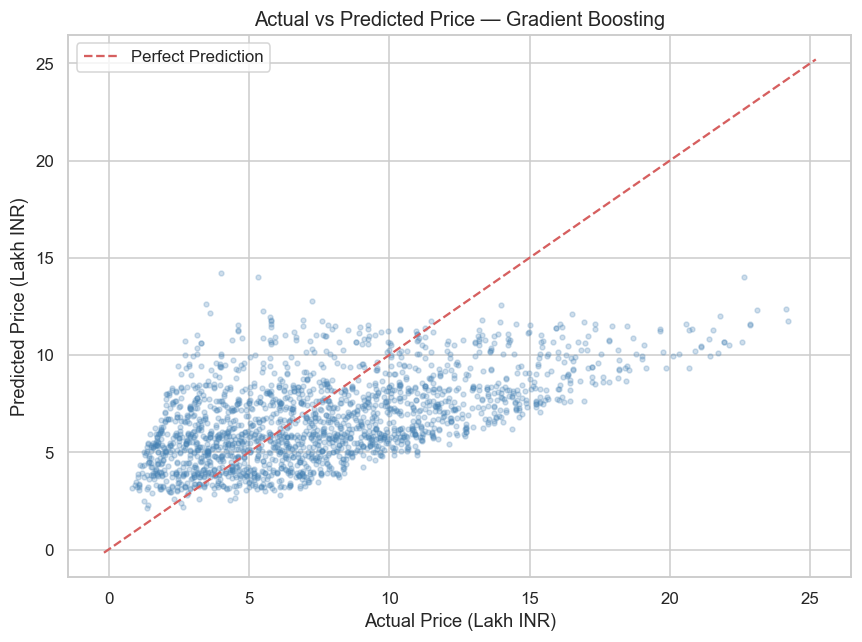

In [26]:
# ── Actual vs Predicted — best model (Gradient Boosting) ─────────────────────
best = results[-1]   # Gradient Boosting is last in the list
# Determine best by R2
best = max(results, key=lambda r: r['R2'])

sample_idx = np.random.default_rng(0).choice(len(best['actuals']), size=2000, replace=False)
act_s = best['actuals'].iloc[sample_idx]
pred_s = best['preds'][sample_idx]

plt.figure(figsize=(8, 6))
plt.scatter(act_s / 1e5, pred_s / 1e5, alpha=0.25, s=10, color='steelblue')
lims = [min(act_s.min(), pred_s.min()) / 1e5 - 1,
        max(act_s.max(), pred_s.max()) / 1e5 + 1]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
plt.title(f'Actual vs Predicted Price — {best["Model"]}', fontsize=13)
plt.xlabel('Actual Price (Lakh INR)')
plt.ylabel('Predicted Price (Lakh INR)')
plt.legend()
plt.tight_layout()
plt.savefig('plot_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

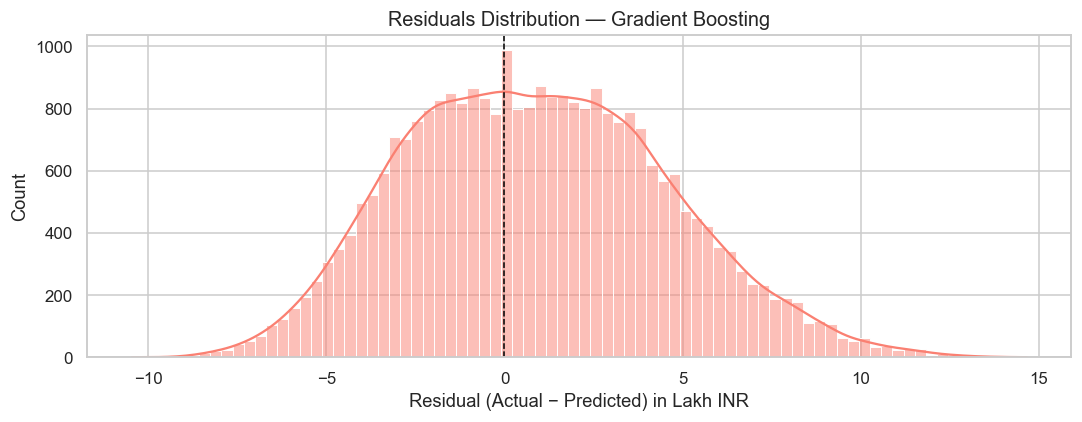

In [27]:
# ── Residuals distribution ────────────────────────────────────────────────────
residuals = best['actuals'] - best['preds']

plt.figure(figsize=(10, 4))
sns.histplot(residuals / 1e5, kde=True, color='salmon', bins=80)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title(f'Residuals Distribution — {best["Model"]}', fontsize=13)
plt.xlabel('Residual (Actual − Predicted) in Lakh INR')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plot_residuals.png', bbox_inches='tight')
plt.show()

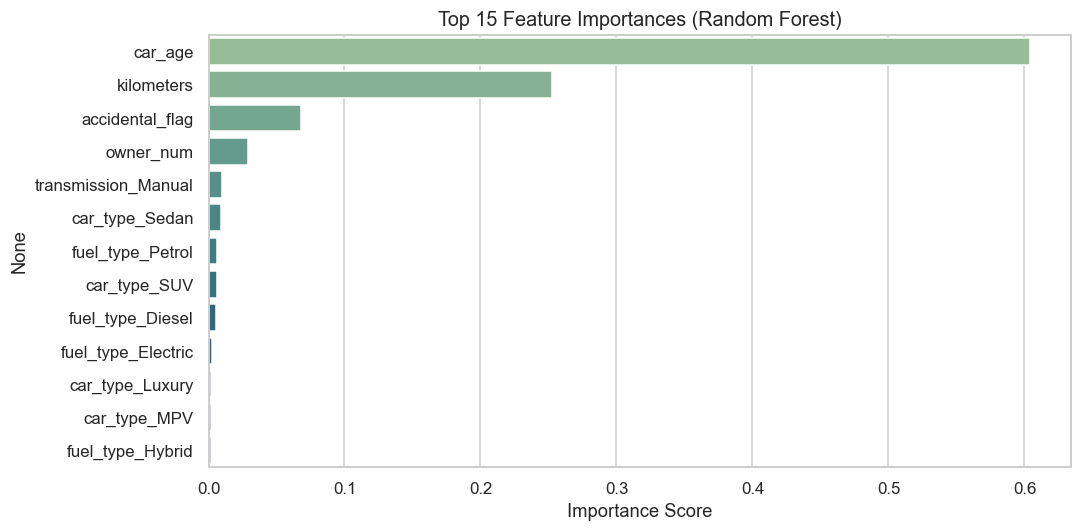

In [28]:
# ── Feature importances (Random Forest) ──────────────────────────────────────
rf_model = next(m for m, _, _, n in models if n == 'Random Forest')
feat_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='crest')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', bbox_inches='tight')
plt.show()

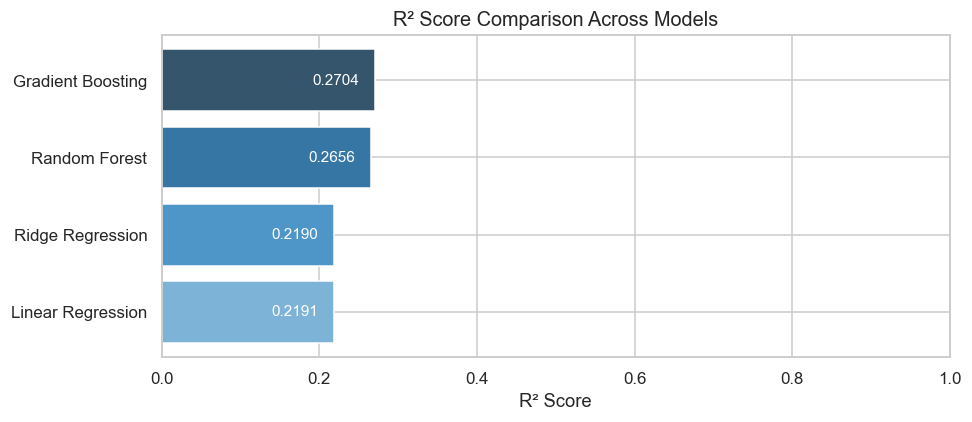

In [29]:
# ── R² comparison bar chart ───────────────────────────────────────────────────
names = [r['Model'] for r in results]
r2s   = [r['R2'] for r in results]

plt.figure(figsize=(9, 4))
bars = plt.barh(names, r2s, color=sns.color_palette('Blues_d', len(names)))
for bar, val in zip(bars, r2s):
    plt.text(val - 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', ha='right', color='white', fontsize=10)
plt.title('R² Score Comparison Across Models', fontsize=13)
plt.xlabel('R² Score')
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('plot_r2_comparison.png', bbox_inches='tight')
plt.show()

---
## 7. Conclusion & Recommendations

### Key Findings

| Finding | Detail |
|---------|--------|
| **Best Model** | Gradient Boosting Regressor achieved the highest R² |
| **Top Price Driver** | `car_age` is the single most important predictor — newer cars command significantly higher prices |
| **Fuel Type Impact** | Electric and CNG cars have higher median prices; Diesel > Petrol for equivalent age/km |
| **Transmission Premium** | Automatic cars sell for ~30–50% more than manual equivalents |
| **Accidental Discount** | Accidental cars sell for a measurable discount (~15–25%) compared to non-accidental |
| **Geographic Demand** | Maharashtra and Delhi NCR dominate listings, indicating high liquidity markets |
| **Odometer Effect** | Higher km readings correlate negatively with price, especially beyond 1,00,000 km |

### Recommendations

1. **Sellers** — List cars before the 5-year mark; depreciation accelerates sharply after age 6.
2. **Buyers** — Electric/CNG cars offer better resale value; target non-accidental, low-km, single-owner listings.
3. **Platform operators** — Deploy the Gradient Boosting model for real-time price suggestions; retrain quarterly to capture market shifts.
4. **Future work** — Include `model_name` embeddings, geographic price indices, and image-quality scores to push R² higher.

In [30]:
# ── Save cleaned dataset for reference ───────────────────────────────────────
df.to_csv('Car_Sell_Dataset_Cleaned.csv', index=False)
print('Cleaned dataset saved as Car_Sell_Dataset_Cleaned.csv')
print(f'Final cleaned shape: {df.shape}')

Cleaned dataset saved as Car_Sell_Dataset_Cleaned.csv
Final cleaned shape: (140904, 15)
